In [1]:
%load_ext autoreload
%autoreload 2

# mPFC Reward Competition Pipeline Comparison

This notebook keeps the normal `Reward_Competition` experiment workflow, but creates multiple `rc_exp`-style experiments with different preprocessing pipelines and compares them.

In [2]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import welch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RC_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

for path in [PROJECT_ROOT, RC_DIR]:
    if path not in sys.path:
        sys.path.append(path)

from rc_extension import Reward_Competition

In [3]:
experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset"
manual_scoring_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\manual_scoring_combined.xlsx"
hvl_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\HvL_comp_scoring_updated.xlsx"

# Trial to visualize across pipelines.
selected_trial = None

# mPFC trials usually start with 'p'. Change if needed.
brain_region_prefix = 'p'

# Plot window for troubleshooting figures.
start_time = 90
end_time = 310

# Shared preprocessing defaults.
target_fs = 100
trim_start = 30
trim_end_default = 10
trim_end_special = {'p1-240614-064528': 30}
lowpass_cutoff = 3.0
highpass_cutoff = 0.001
irls_constant = 3.0
zscore_method = 'standard'

# Downstream DA analysis settings if manual scoring is available.
run_behavior_analysis = manual_scoring_path is not None
tone_window = (-5, 10)
pe_window = (0, 10)
baseline_window = (-20, -10)

## Helper functions

In [4]:
def mad(arr):
    arr = np.asarray(arr, dtype=float)
    median = np.nanmedian(arr)
    return float(np.nanmedian(np.abs(arr - median)))


def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    return float(np.corrcoef(x[mask], y[mask])[0, 1])


def bandpower_fraction(signal, fs, band):
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]
    if signal.size < 8:
        return np.nan

    freqs, power = welch(signal, fs=fs, nperseg=min(2048, signal.size))
    total_power = np.trapz(power, freqs)
    if total_power <= 0:
        return np.nan

    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)
    if not np.any(mask):
        return np.nan

    band_power = np.trapz(power[mask], freqs[mask])
    return float(band_power / total_power)


def transient_snr(signal):
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]
    if signal.size < 8:
        return np.nan

    noise = mad(np.diff(signal))
    if noise == 0:
        return np.nan
    return float(np.nanstd(signal) / noise)


def apply_common_behavior_mapping(exp, trial_name, trial):
    trial.rtc_events['sound cues'] = trial.rtc_events.pop('PC0_')

    if trial_name in exp.port_bnc:
        port_val = exp.port_bnc[trial_name]
        if port_val == 3:
            trial.rtc_events['port entries'] = trial.rtc_events.pop('PC3_')
        elif port_val == 2:
            trial.rtc_events['port entries'] = trial.rtc_events.pop('PC2_')
        else:
            print(f'Warning: unexpected port value {port_val} for {trial_name}')
    else:
        if 'PC2_' in trial.rtc_events:
            trial.rtc_events['port entries'] = trial.rtc_events.pop('PC2_')
        elif 'PC3_' in trial.rtc_events:
            trial.rtc_events['port entries'] = trial.rtc_events.pop('PC3_')
        else:
            print(f'Warning: no port entries channel found for {trial_name}')

    trial.rtc_events['sound cues'].onset_times = trial.rtc_events['sound cues'].onset[1:]
    trial.rtc_events['sound cues'].offset_times = trial.rtc_events['sound cues'].offset[1:]
    trial.rtc_events['port entries'].onset_times = trial.rtc_events['port entries'].onset[1:]
    trial.rtc_events['port entries'].offset_times = trial.rtc_events['port entries'].offset[1:]

    valid_sound_cues = [t for t in trial.rtc_events['sound cues'].onset_times if t >= 200]
    trial.rtc_events['sound cues'].onset_times = valid_sound_cues


def process_trial_with_pipeline(trial_name, trial, pipeline_name):
    trial.downsample(target_fs=target_fs)
    trial.remove_initial_LED_artifact(t=trim_start)

    trim_end = trim_end_special.get(trial_name, trim_end_default)
    if trim_end > 0:
        trial.remove_final_data_segment(t=trim_end)

    if pipeline_name in ['current_default', 'no_highpass', 'highpass_after_dff', 'double_exp_detrend']:
        trial.lowpass_filter(cutoff_hz=lowpass_cutoff)

    if pipeline_name == 'current_default':
        trial.baseline_drift_highpass_recentered(cutoff=highpass_cutoff)
    elif pipeline_name == 'double_exp_detrend':
        trial.basline_drift_double_exponential()

    trial.motion_correction_align_channels_IRLS(IRLS_constant=irls_constant)
    trial.compute_dFF()

    if pipeline_name == 'highpass_after_dff':
        trial.highpass_baseline_drift_dFF(cutoff=highpass_cutoff)

    trial.compute_zscore(method=zscore_method)


def build_rc_experiment(experiment_path, pipeline_name):
    rc_exp = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=None)
    rc_exp.pipeline_name = pipeline_name

    for trial_name, trial in rc_exp.trials.items():
        print(f'[{pipeline_name}] Processing {trial_name}...')
        process_trial_with_pipeline(trial_name, trial, pipeline_name)
        apply_common_behavior_mapping(rc_exp, trial_name, trial)

    if run_behavior_analysis:
        rc_exp.read_and_merge_manual_scoring(manual_scoring_path)
        rc_exp.remove_specified_subjects()
        if hvl_path is not None:
            rc_exp.read_hvl_scoring(hvl_path)
        rc_exp.remove_tangles(placeholders=True)
        rc_exp.extract_da_columns()
        rc_exp.find_first_port_entry_after_sound_cue()
        rc_exp.compute_EI_DA(
            tone_window=tone_window,
            pe_window=pe_window,
            baseline_window=baseline_window,
        )

    return rc_exp


def summarize_experiment(rc_exp, brain_prefix='p'):
    rows = []
    for trial_name, trial in rc_exp.trials.items():
        if brain_prefix and not trial_name.startswith(brain_prefix):
            continue

        residual = np.asarray(trial.updated_DA - trial.isosbestic_fitted, dtype=float)
        rows.append({
            'pipeline': rc_exp.pipeline_name,
            'trial_name': trial_name,
            'da_fit_corr': safe_corr(trial.updated_DA, trial.isosbestic_fitted),
            'residual_mad': mad(residual),
            'residual_mean_abs': float(np.nanmean(np.abs(residual))),
            'dff_std': float(np.nanstd(trial.dFF)),
            'zscore_std': float(np.nanstd(trial.zscore)),
            'low_freq_fraction_lt_0p01Hz': bandpower_fraction(trial.dFF, trial.fs, (0.0, 0.01)),
            'signal_fraction_0p01_to_0p5Hz': bandpower_fraction(trial.dFF, trial.fs, (0.01, 0.5)),
            'transient_snr': transient_snr(trial.dFF),
        })
    return pd.DataFrame(rows)


def window_mask(timestamps, start_time=None, end_time=None):
    mask = np.ones_like(timestamps, dtype=bool)
    if start_time is not None:
        mask &= timestamps >= start_time
    if end_time is not None:
        mask &= timestamps <= end_time
    return mask


def plot_selected_trial_across_experiments(experiments, trial_name, start_time=None, end_time=None):
    fig, axes = plt.subplots(len(experiments), 3, figsize=(18, 4 * len(experiments)), sharex=False)
    if len(experiments) == 1:
        axes = np.array([axes])

    for row_idx, (pipeline_name, rc_exp) in enumerate(experiments.items()):
        if trial_name not in rc_exp.trials:
            raise KeyError(f'{trial_name} not found in {pipeline_name}')

        trial = rc_exp.trials[trial_name]
        mask = window_mask(trial.timestamps, start_time=start_time, end_time=end_time)
        t = trial.timestamps[mask]

        ax0, ax1, ax2 = axes[row_idx]

        ax0.plot(t, trial.updated_DA[mask], color='steelblue', linewidth=1.2, label='DA')
        ax0.plot(t, trial.updated_ISOS[mask], color='darkorange', linewidth=1.2, label='ISOS')
        ax0.set_title(f'{pipeline_name}: DA vs ISOS')
        ax0.set_ylabel('Voltage (V)')
        ax0.grid(alpha=0.3)
        if row_idx == 0:
            ax0.legend(loc='upper right')

        ax1.plot(t, trial.updated_DA[mask], color='steelblue', linewidth=1.2, label='DA')
        ax1.plot(t, trial.isosbestic_fitted[mask], color='darkorange', linewidth=1.2, label='Fitted ISOS')
        ax1.set_title(f'{pipeline_name}: IRLS fit')
        ax1.grid(alpha=0.3)
        if row_idx == 0:
            ax1.legend(loc='upper right')

        ax2.plot(t, trial.dFF[mask], color='green', linewidth=1.2, label='dF/F')
        ax2.plot(t, trial.zscore[mask], color='purple', linewidth=1.0, alpha=0.8, label='z-score')
        ax2.set_title(f'{pipeline_name}: normalized output')
        ax2.set_xlabel('Time (s)')
        ax2.grid(alpha=0.3)
        if row_idx == 0:
            ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def compare_event_metrics(experiments, brain_prefix='p'):
    rows = []
    for pipeline_name, rc_exp in experiments.items():
        if not hasattr(rc_exp, 'da_df') or rc_exp.da_df.empty:
            continue

        df = rc_exp.da_df.copy()
        df = df[df['subject_name'].str.startswith(brain_prefix)]
        if df.empty:
            continue

        tone_lengths = df['Tone_Zscore'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        pe_lengths = df['PE_Zscore'].apply(lambda x: len(x) if isinstance(x, list) else 0)

        rows.append({
            'pipeline': pipeline_name,
            'n_sessions': len(df),
            'mean_tone_events_per_session': float(np.nanmean(tone_lengths)),
            'mean_pe_events_per_session': float(np.nanmean(pe_lengths)),
        })

    return pd.DataFrame(rows)

## Build multiple `rc_exp` experiments

Each experiment starts from the same `Reward_Competition` object and then gets its own preprocessing pipeline.

In [5]:
rc_exp_current_default = build_rc_experiment(experiment_path, 'current_default')
rc_exp_no_highpass = build_rc_experiment(experiment_path, 'no_highpass')
rc_exp_highpass_after_dff = build_rc_experiment(experiment_path, 'highpass_after_dff')
rc_exp_double_exp_detrend = build_rc_experiment(experiment_path, 'double_exp_detrend')
rc_exp_raw_irls_only = build_rc_experiment(experiment_path, 'raw_irls_only')

experiments = {
    'current_default': rc_exp_current_default,
    'no_highpass': rc_exp_no_highpass,
    'highpass_after_dff': rc_exp_highpass_after_dff,
    'double_exp_detrend': rc_exp_double_exp_detrend,
    'raw_irls_only': rc_exp_raw_irls_only,
}

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coer

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coer

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coer

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coer

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:474: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[pre_cols]  = hv[pre_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coerce')
c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\rc_extension.py:475: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hv[comp_cols] = hv[comp_cols].replace('T', np.nan).apply(pd.to_numeric, errors='coer

## Trial-level comparison summary

In [6]:
comparison_df = pd.concat(
    [summarize_experiment(rc_exp, brain_prefix=brain_region_prefix) for rc_exp in experiments.values()],
    ignore_index=True,
)

display(comparison_df)

aggregate_summary = (
    comparison_df.groupby('pipeline')[
        [
            'da_fit_corr',
            'residual_mad',
            'residual_mean_abs',
            'dff_std',
            'zscore_std',
            'low_freq_fraction_lt_0p01Hz',
            'signal_fraction_0p01_to_0p5Hz',
            'transient_snr',
        ]
    ]
    .mean(numeric_only=True)
    .sort_values(['residual_mad', 'low_freq_fraction_lt_0p01Hz'])
)

display(aggregate_summary)

,pipeline,trial_name,da_fit_corr,residual_mad,residual_mean_abs,dff_std,zscore_std,low_freq_fraction_lt_0p01Hz,signal_fraction_0p01_to_0p5Hz,transient_snr
0,current_default,pp4-250203-121223,0.877800,0.703853,0.839604,0.008129,1.0,0.0,0.307612,19.072696
1,current_default,pp5-250203-080636,0.938163,1.341992,1.696197,0.007268,1.0,0.0,0.528773,32.501775
2,current_default,pp7-250205-131504,0.727125,0.386565,0.516418,0.004666,1.0,0.0,0.557947,27.609244
3,current_default,pp8-250206-102501,0.856224,0.770110,0.930727,0.008356,1.0,0.0,0.353353,20.445624
4,current_default,p5-240912-071257,0.922171,1.027249,1.269252,0.007811,1.0,0.0,0.594599,54.643582
...,...,...,...,...,...,...,...,...,...,...
75,raw_irls_only,p7-240914-074210,0.826745,2.695677,3.091756,0.013993,1.0,0.0,0.669392,51.697614
76,raw_irls_only,p8-240913-070924,0.904690,1.914344,2.298402,0.011762,1.0,0.0,0.685109,35.597112
77,raw_irls_only,p8-240914-061235,0.938261,1.599740,2.128420,0.012120,1.0,0.0,0.674038,36.268364
78,raw_irls_only,p8-240915-051905,0.931184,1.652858,2.162919,0.012000,1.0,0.0,0.648870,37.431010


,da_fit_corr,residual_mad,residual_mean_abs,dff_std,zscore_std,low_freq_fraction_lt_0p01Hz,signal_fraction_0p01_to_0p5Hz,transient_snr
pipeline,,,,,,,,
current_default,0.912697,1.059117,1.333975,0.007894,1.0,0.0,0.569867,52.026542
double_exp_detrend,0.900833,1.103262,1.431877,0.008467,1.0,0.0,0.585599,57.445360
highpass_after_dff,0.894346,1.660559,2.008459,0.010048,1.0,0.0,0.616847,75.608235
no_highpass,0.894346,1.660559,2.008459,0.011567,1.0,0.0,0.616842,87.304330
raw_irls_only,0.882078,1.724993,2.078909,0.012088,1.0,0.0,0.562527,33.043289


## Compare one trial across pipelines

In [7]:
if selected_trial is None:
    mpfc_trials = [name for name in rc_exp_current_default.trials if name.startswith(brain_region_prefix)]
    selected_trial = mpfc_trials[0]

print(f'Selected trial: {selected_trial}')

Selected trial: pp4-250203-121223


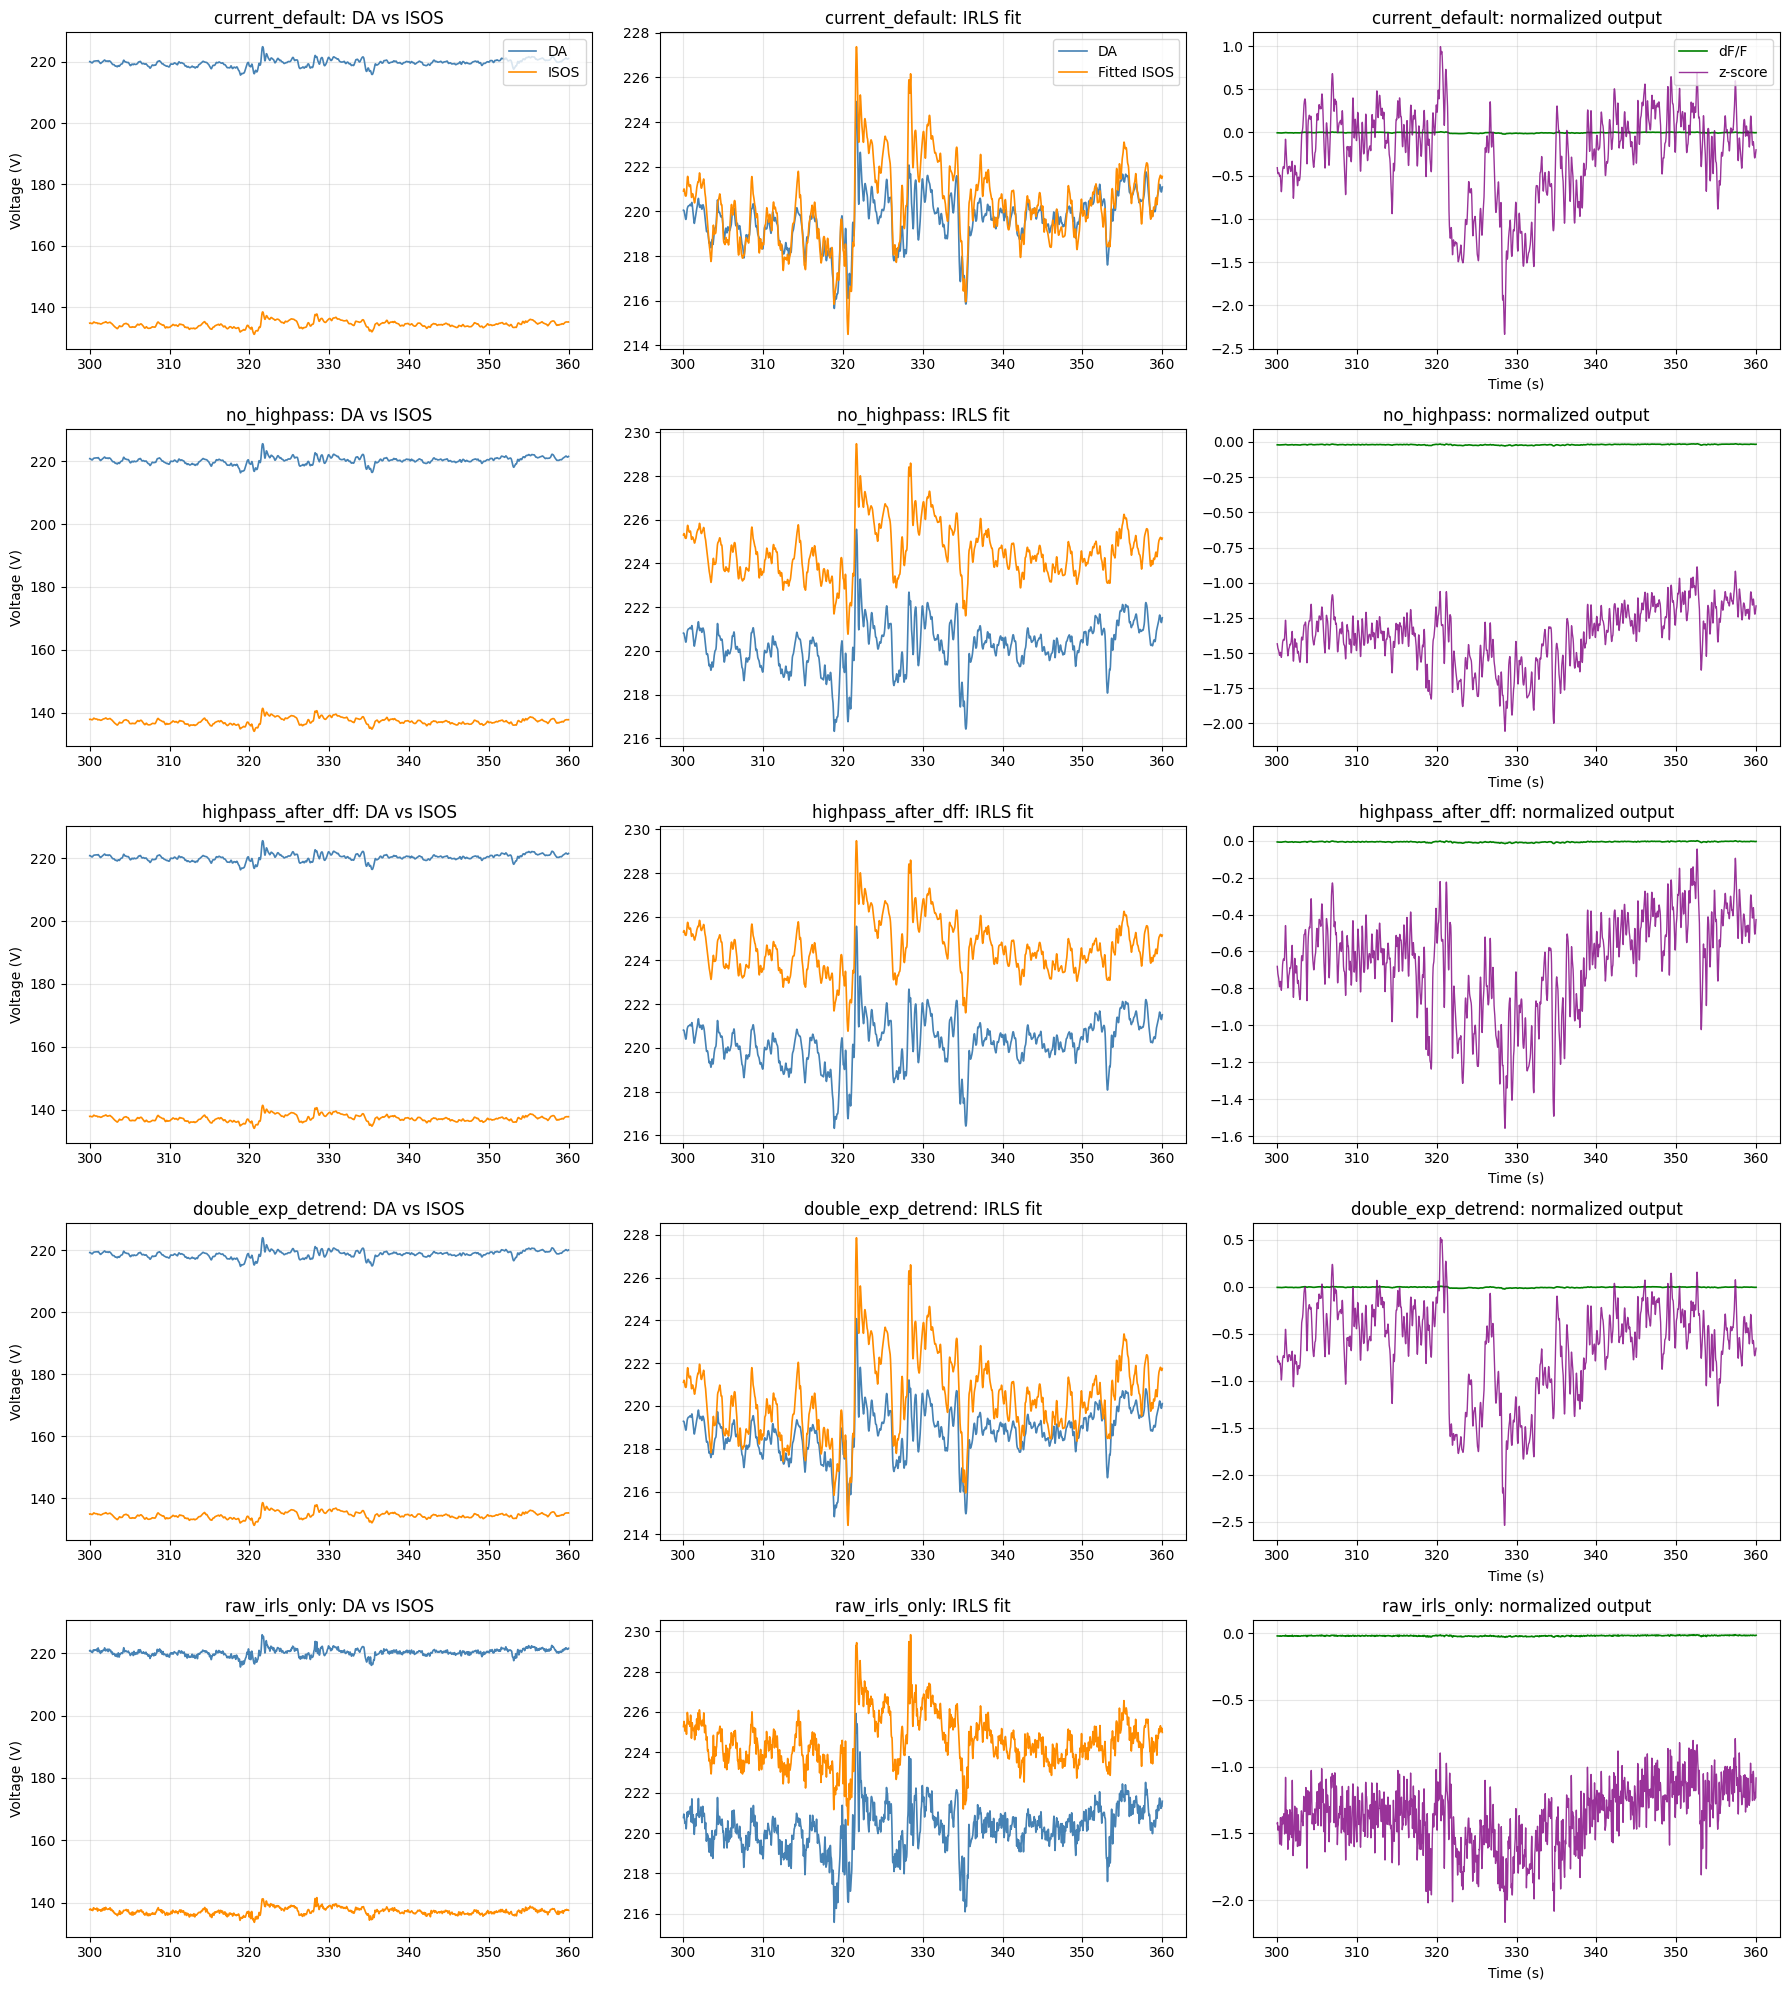

In [8]:
plot_selected_trial_across_experiments(
    experiments,
    trial_name='p8-240915-081607',
    start_time=300,
    end_time=360,
)

## Selected trial metrics only

In [9]:
selected_trial_metrics = comparison_df[comparison_df['trial_name'] == selected_trial].sort_values('pipeline')
display(selected_trial_metrics)

,pipeline,trial_name,da_fit_corr,residual_mad,residual_mean_abs,dff_std,zscore_std,low_freq_fraction_lt_0p01Hz,signal_fraction_0p01_to_0p5Hz,transient_snr
0,current_default,pp4-250203-121223,0.877800,0.703853,0.839604,0.008129,1.0,0.0,0.307612,19.072696
48,double_exp_detrend,pp4-250203-121223,0.862934,0.755616,0.899349,0.008725,1.0,0.0,0.312390,20.602875
32,highpass_after_dff,pp4-250203-121223,0.966209,0.957874,1.123147,0.009772,1.0,0.0,0.216280,17.079222
16,no_highpass,pp4-250203-121223,0.966209,0.957874,1.123147,0.010836,1.0,0.0,0.216283,18.938722
64,raw_irls_only,pp4-250203-121223,0.940939,1.258052,1.478225,0.014233,1.0,0.0,0.090119,7.963757


## Optional downstream behavior comparison

If you provide `manual_scoring_path`, this cell will show a simple session-level comparison after the preprocessing differences propagate through the normal RC DA workflow.

In [10]:
if run_behavior_analysis:
    event_summary = compare_event_metrics(experiments, brain_prefix=brain_region_prefix)
    display(event_summary)
else:
    print('manual_scoring_path is None, so downstream behavior analysis was skipped.')

,pipeline,n_sessions,mean_tone_events_per_session,mean_pe_events_per_session
0,current_default,16,20.0,20.0
1,no_highpass,16,20.0,20.0
2,highpass_after_dff,16,20.0,20.0
3,double_exp_detrend,16,20.0,20.0
4,raw_irls_only,16,20.0,20.0


## How to read the comparison

- Lower `residual_mad` usually means less mismatch between DA and the fitted isosbestic.
- Lower `low_freq_fraction_lt_0p01Hz` usually means less residual slow drift in `dF/F`.
- Higher `transient_snr` usually means more preserved dynamics relative to point-to-point noise.
- For mPFC, the most useful first read is usually the direct visual comparison of the same trial across `current_default`, `no_highpass`, and `highpass_after_dff`.

## Separate IRLS Constant Analysis

This section keeps the preprocessing path fixed to the current default pipeline (`low-pass -> high-pass on channels -> IRLS -> dF/F`) and varies only the Tukey biweight constant used by IRLS.

In [11]:
irls_constants_to_compare = [1.5, 2.0, 3.0, 4.0, 5.0]

# Set True if you also want manual-scoring-based DA analysis for each IRLS constant.
# Leaving this False makes the sweep much faster.
run_behavior_analysis_for_irls_sweep = False

In [12]:
def process_trial_with_irls_constant(trial_name, trial, irls_constant_value):
    trial.downsample(target_fs=target_fs)
    trial.remove_initial_LED_artifact(t=trim_start)

    trim_end = trim_end_special.get(trial_name, trim_end_default)
    if trim_end > 0:
        trial.remove_final_data_segment(t=trim_end)

    trial.lowpass_filter(cutoff_hz=lowpass_cutoff)
    trial.baseline_drift_highpass_recentered(cutoff=highpass_cutoff)
    trial.motion_correction_align_channels_IRLS(IRLS_constant=irls_constant_value)
    trial.compute_dFF()
    trial.compute_zscore(method=zscore_method)


def build_rc_experiment_for_irls_constant(experiment_path, irls_constant_value, run_behavior=False):
    rc_exp = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=None)
    rc_exp.pipeline_name = f'irls_{irls_constant_value:g}'
    rc_exp.irls_constant = irls_constant_value

    for trial_name, trial in rc_exp.trials.items():
        print(f'[irls={irls_constant_value:g}] Processing {trial_name}...')
        process_trial_with_irls_constant(trial_name, trial, irls_constant_value)
        apply_common_behavior_mapping(rc_exp, trial_name, trial)

    if run_behavior:
        rc_exp.read_and_merge_manual_scoring(manual_scoring_path)
        rc_exp.remove_specified_subjects()
        if hvl_path is not None:
            rc_exp.read_hvl_scoring(hvl_path)
        rc_exp.remove_tangles(placeholders=True)
        rc_exp.extract_da_columns()
        rc_exp.find_first_port_entry_after_sound_cue()
        rc_exp.compute_EI_DA(
            tone_window=tone_window,
            pe_window=pe_window,
            baseline_window=baseline_window,
        )

    return rc_exp


def rank_irls_constant_summary(metrics_df):
    ranked = metrics_df.copy()
    ranked['fit_rank'] = ranked['da_fit_corr'].rank(ascending=False, method='min')
    ranked['residual_rank'] = ranked['residual_mad'].rank(ascending=True, method='min')
    ranked['drift_rank'] = ranked['low_freq_fraction_lt_0p01Hz'].rank(ascending=True, method='min')
    ranked['snr_rank'] = ranked['transient_snr'].rank(ascending=False, method='min')
    ranked['composite_rank_score'] = (
        ranked['fit_rank'] + ranked['residual_rank'] + ranked['drift_rank'] + ranked['snr_rank']
    )
    return ranked.sort_values(['composite_rank_score', 'residual_mad', 'low_freq_fraction_lt_0p01Hz', 'irls_constant'])

In [13]:
irls_experiments = {}
for irls_c in irls_constants_to_compare:
    irls_experiments[f'irls_{irls_c:g}'] = build_rc_experiment_for_irls_constant(
        experiment_path,
        irls_constant_value=irls_c,
        run_behavior=run_behavior_analysis_for_irls_sweep,
    )

irls_comparison_df = pd.concat(
    [summarize_experiment(rc_exp, brain_prefix=brain_region_prefix) for rc_exp in irls_experiments.values()],
    ignore_index=True,
)
irls_comparison_df['irls_constant'] = irls_comparison_df['pipeline'].str.replace('irls_', '', regex=False).astype(float)

irls_summary_df = (
    irls_comparison_df.groupby(['pipeline', 'irls_constant'], as_index=False)
    .agg({
        'da_fit_corr': 'mean',
        'residual_mad': 'mean',
        'residual_mean_abs': 'mean',
        'dff_std': 'mean',
        'zscore_std': 'mean',
        'low_freq_fraction_lt_0p01Hz': 'mean',
        'signal_fraction_0p01_to_0p5Hz': 'mean',
        'transient_snr': 'mean',
    })
)

irls_ranked_df = rank_irls_constant_summary(irls_summary_df)
display(irls_ranked_df)

read from t=0s to t=2065.26s
read from t=0s to t=2065.26s
read from t=0s to t=2072.35s
read from t=0s to t=2072.35s
read from t=0s to t=2046.06s
read from t=0s to t=2046.06s
read from t=0s to t=2065.37s
read from t=0s to t=2065.37s
read from t=0s to t=2044.26s
read from t=0s to t=2044.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240912-071257\Notes.txt
read from t=0s to t=2045.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240913-085922\Notes.txt
read from t=0s to t=2044.47s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p5-240915-064653\Notes.txt
read from t=0s to t=2050.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\testset\p6-240912-052842\Notes.txt
read fr

,pipeline,irls_constant,da_fit_corr,residual_mad,residual_mean_abs,dff_std,zscore_std,low_freq_fraction_lt_0p01Hz,signal_fraction_0p01_to_0p5Hz,transient_snr,fit_rank,residual_rank,drift_rank,snr_rank,composite_rank_score
0,irls_1.5,1.5,0.912697,1.054775,1.359030,0.008061,1.0,0.0,0.594253,54.443049,1.0,2.0,1.0,1.0,5.0
1,irls_2,2.0,0.912697,1.054650,1.344878,0.007982,1.0,0.0,0.585863,53.209496,3.0,1.0,1.0,2.0,7.0
2,irls_3,3.0,0.912697,1.059117,1.333975,0.007894,1.0,0.0,0.569867,52.026542,2.0,3.0,1.0,3.0,9.0
3,irls_4,4.0,0.912697,1.061698,1.333401,0.007881,1.0,0.0,0.567479,51.821108,3.0,4.0,1.0,4.0,12.0
4,irls_5,5.0,0.912697,1.063574,1.334144,0.007876,1.0,0.0,0.566575,51.754479,5.0,5.0,1.0,5.0,16.0


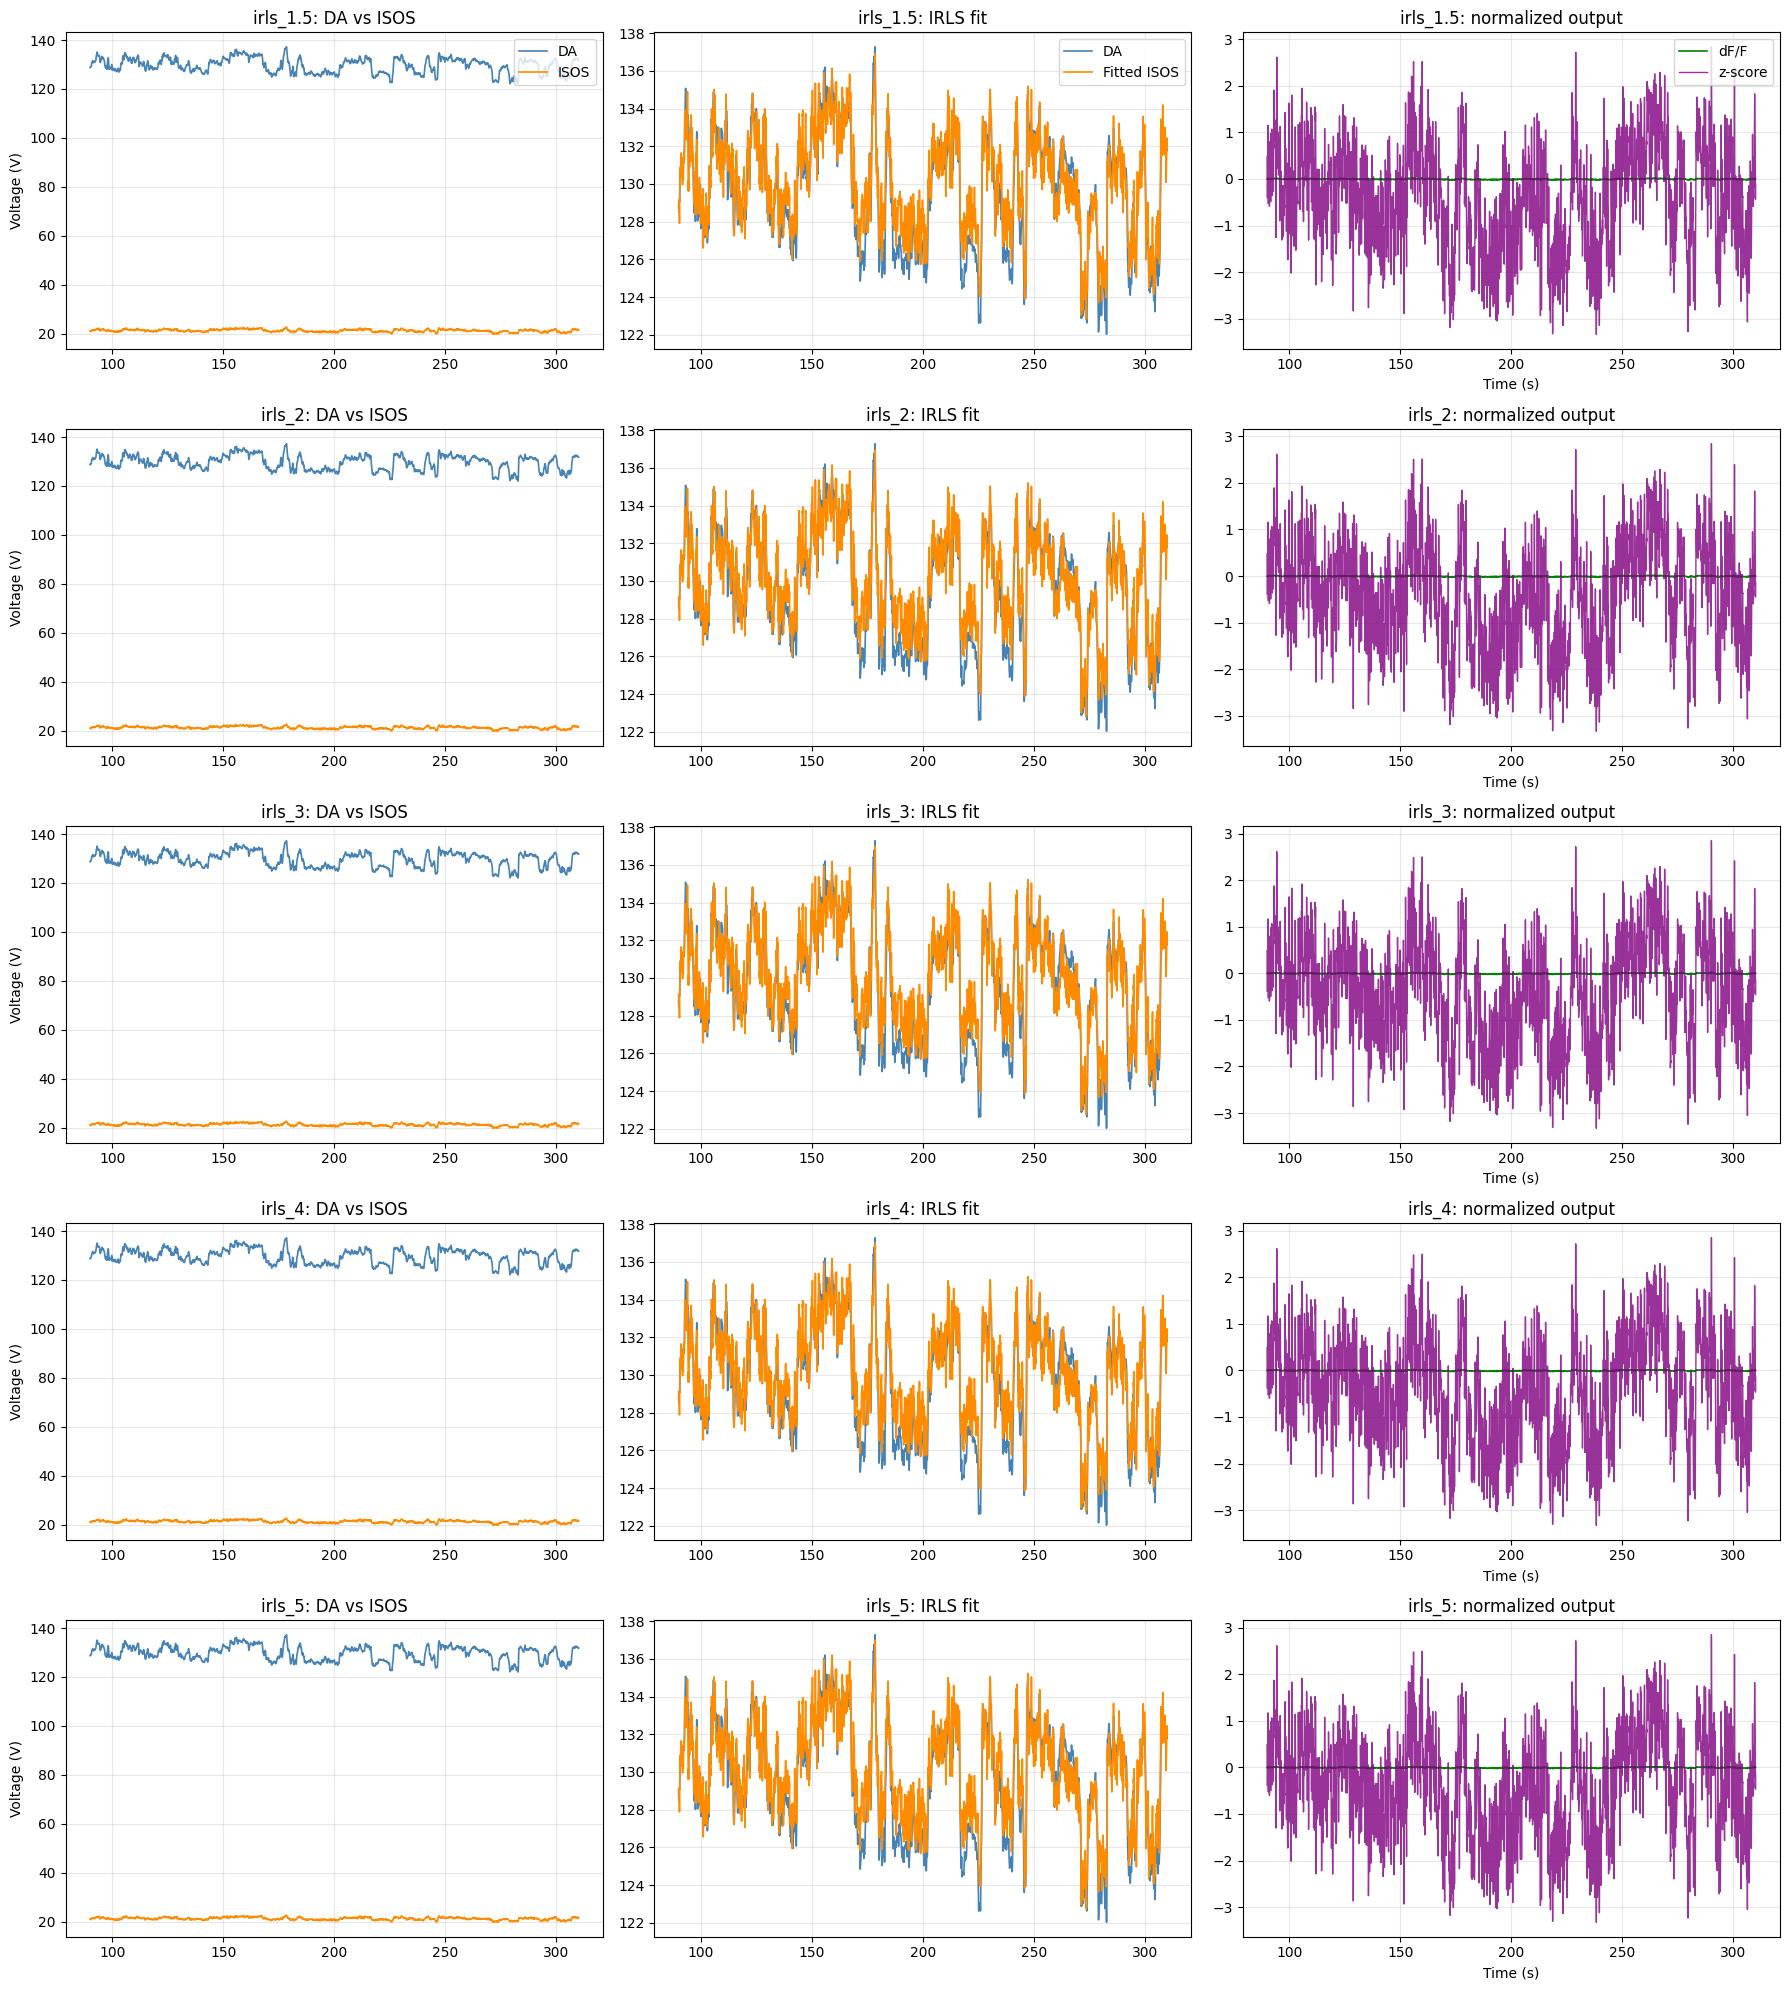

,pipeline,trial_name,da_fit_corr,residual_mad,residual_mean_abs,dff_std,zscore_std,low_freq_fraction_lt_0p01Hz,signal_fraction_0p01_to_0p5Hz,transient_snr,irls_constant
0,irls_1.5,pp4-250203-121223,0.8778,0.703944,0.839666,0.008129,1.0,0.0,0.313445,19.226745,1.5
16,irls_2,pp4-250203-121223,0.8778,0.703894,0.839612,0.008129,1.0,0.0,0.311315,19.171097,2.0
32,irls_3,pp4-250203-121223,0.8778,0.703853,0.839604,0.008129,1.0,0.0,0.307612,19.072696,3.0
48,irls_4,pp4-250203-121223,0.8778,0.703676,0.839627,0.008129,1.0,0.0,0.306553,19.047658,4.0
64,irls_5,pp4-250203-121223,0.8778,0.703672,0.839631,0.008129,1.0,0.0,0.306386,19.043650,5.0


In [14]:
plot_selected_trial_across_experiments(
    irls_experiments,
    trial_name=selected_trial,
    start_time=start_time,
    end_time=end_time,
)

irls_selected_trial_metrics = (
    irls_comparison_df[irls_comparison_df['trial_name'] == selected_trial]
    .sort_values('irls_constant')
)
display(irls_selected_trial_metrics)